Dados carregados: 1020 registros
Período: 2023-07-01 a 2026-04-15
Visualizações — min: 865 | max: 68,325 | média: 28,890



00:24:30 - cmdstanpy - INFO - Chain [1] start processing
00:24:31 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


Executando validação cruzada... (pode levar alguns segundos)

  MÉTRICAS DE VALIDAÇÃO CRUZADA
  MAPE médio : 41.7%
  MAE médio  : 5,224 visualizações
  RMSE médio : 7,575 visualizações

MAPE por horizonte (primeiros 10 dias):
 horizon_days  mape_pct
            1 12.135276
            2 21.337248
            3 28.843969
            4 16.506773
            5 11.865391
            6  6.694933
            7 10.630453
            8 14.721287
            9 17.076607
           10 16.416788

Gráfico salvo: prophet_visualizacoes.png
Previsão exportada: previsao_visualizacoes.csv

Data             Previsão       Mínimo       Máximo
----------------------------------------------------
2026-04-16         33,402       27,615       39,423
2026-04-17         28,684       22,563       34,750
2026-04-18          5,471       -1,438       11,643
2026-04-19          5,338         -657       12,028
2026-04-20         36,767       30,225       42,928
2026-04-21         35,675       29,391       41,725
202

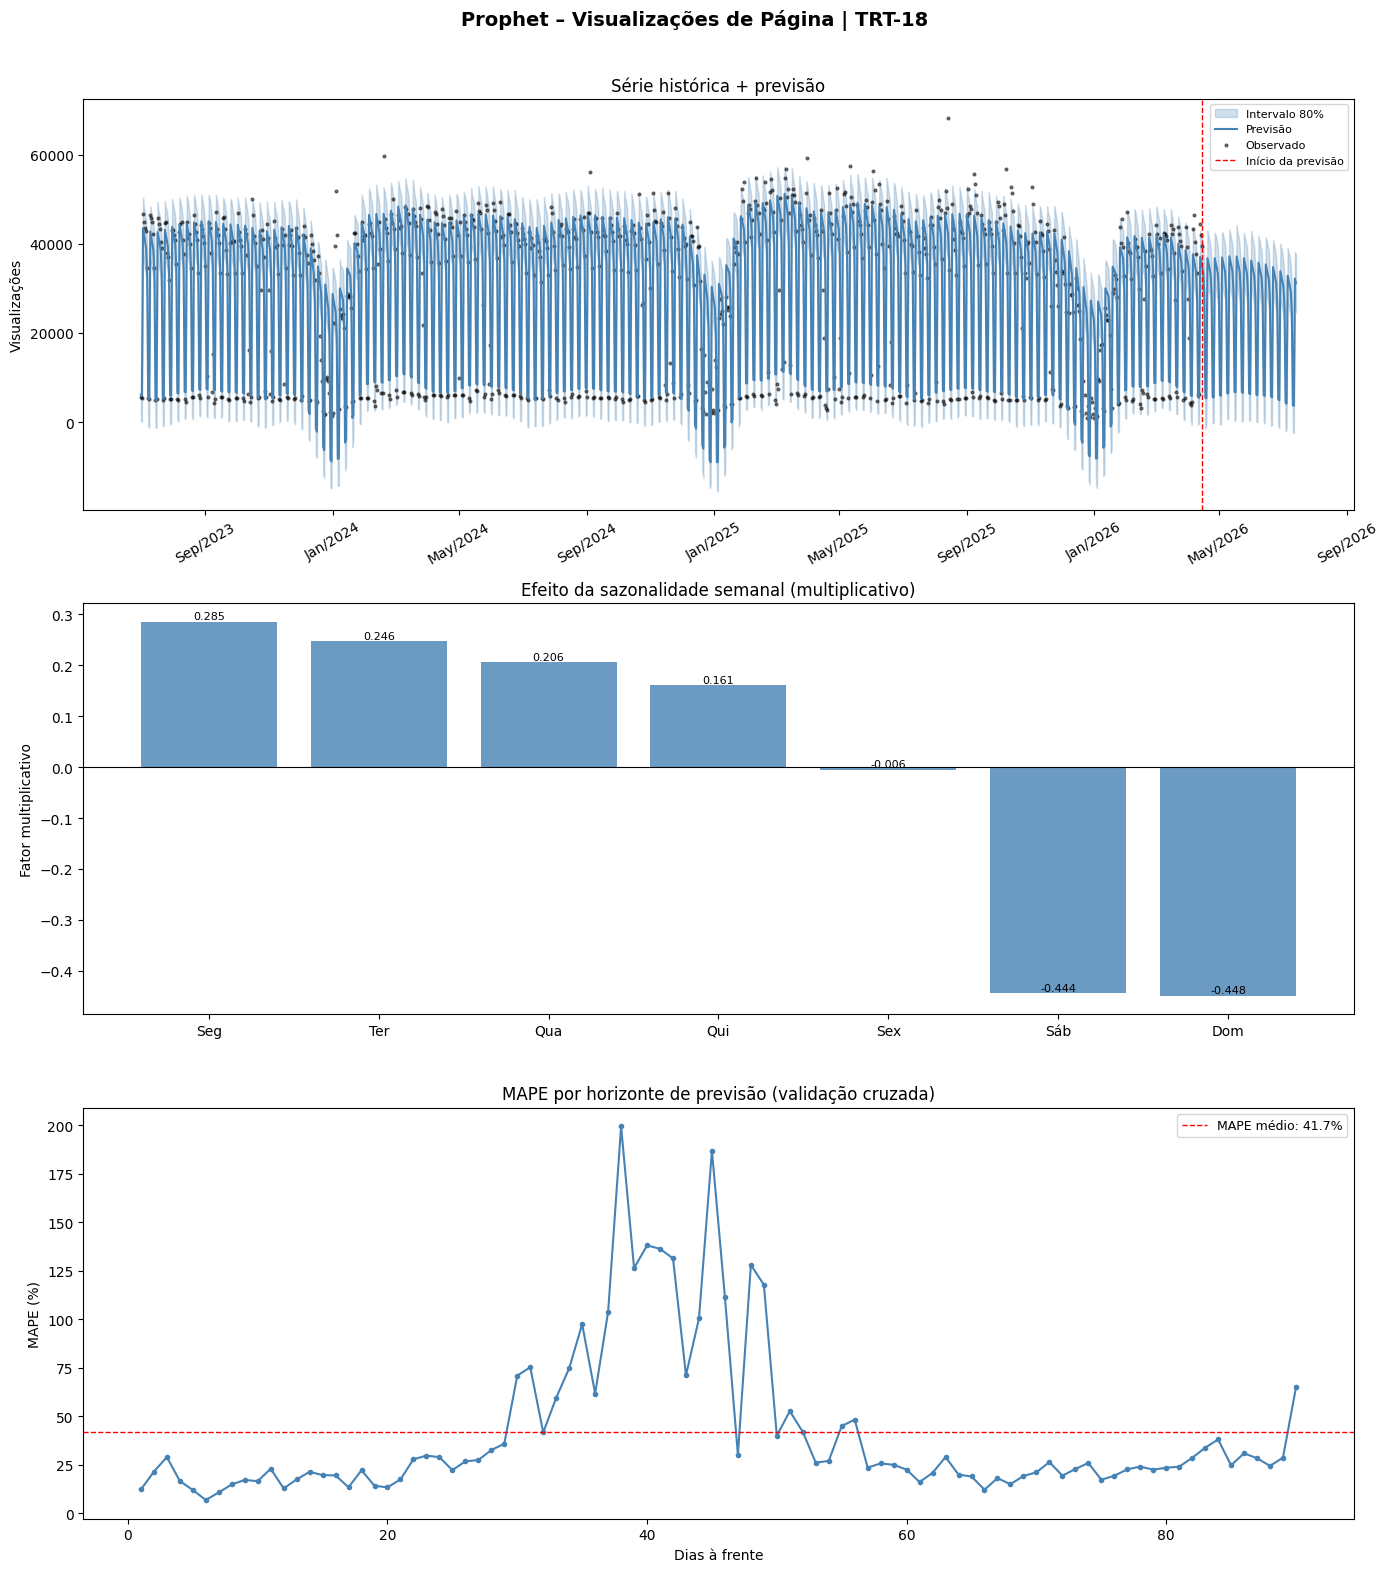

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
 
# =============================================================================
# 1. CARREGAMENTO DOS DADOS
# =============================================================================
 
CSV_PATH = "../dados/trafego_prophet_visualizacoes.csv"  # ajuste o caminho se necessário
 
df = pd.read_csv(CSV_PATH)
df["ds"] = pd.to_datetime(df["ds"])
 
print(f"Dados carregados: {len(df)} registros")
print(f"Período: {df['ds'].min().date()} a {df['ds'].max().date()}")
print(f"Visualizações — min: {df['y'].min():,} | max: {df['y'].max():,} | média: {df['y'].mean():,.0f}")
print()
 
# =============================================================================
# 2. MODELO PROPHET
# =============================================================================
 
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",  # padrão robusto para dados com variância proporcional
    changepoint_prior_scale=0.05,       # controle de flexibilidade da tendência
    seasonality_prior_scale=10,         # flexibilidade das sazonalidades
)
 
# Regressores externos (variáveis binárias do calendário judicial)
regressores = [
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda",
]
 
for reg in regressores:
    model.add_regressor(reg, standardize=False)
 
# Treino com todos os dados históricos
model.fit(df)
 
# =============================================================================
# 3. PREVISÃO FUTURA (90 dias)
# =============================================================================
 
HORIZONTE_DIAS = 90
 
future = model.make_future_dataframe(periods=HORIZONTE_DIAS)
 
# Preencher regressores no período futuro
# Calendário simplificado: fim de semana automático; demais feriados = 0 por padrão
for reg in regressores:
    if reg in future.columns:
        continue
    future[reg] = 0
 
# fim_de_semana com base no dia da semana (0=segunda ... 6=domingo)
future["fim_de_semana"] = future["ds"].dt.dayofweek.isin([5, 6]).astype(int)
 
# Mesclar os regressores históricos conhecidos (para o período já observado)
future = future.merge(
    df[["ds"] + regressores],
    on="ds",
    how="left",
    suffixes=("", "_hist"),
)
 
for reg in regressores:
    col_hist = reg + "_hist"
    if col_hist in future.columns:
        future[reg] = future[reg].combine_first(future[col_hist])
        future.drop(columns=[col_hist], inplace=True)
 
future[regressores] = future[regressores].fillna(0).astype(int)
 
forecast = model.predict(future)
 
# =============================================================================
# 4. VALIDAÇÃO CRUZADA
# =============================================================================
 
print("Executando validação cruzada... (pode levar alguns segundos)")
 
# initial: janela de treino inicial
# period:  intervalo entre cortes
# horizon: quanto o modelo precisa prever em cada corte
cv_results = cross_validation(
    model,
    initial="365 days",   # ~1 ano de treino inicial
    period="60 days",     # novo corte a cada 60 dias
    horizon="90 days",    # prevê 90 dias à frente
    parallel="processes",
)
 
metrics = performance_metrics(cv_results, rolling_window=1)
 
# Extrai MAPE médio geral
mape_medio = metrics["mape"].mean() * 100
mae_medio  = metrics["mae"].mean()
rmse_medio = metrics["rmse"].mean()
 
print()
print("=" * 50)
print("  MÉTRICAS DE VALIDAÇÃO CRUZADA")
print("=" * 50)
print(f"  MAPE médio : {mape_medio:.1f}%")
print(f"  MAE médio  : {mae_medio:,.0f} visualizações")
print(f"  RMSE médio : {rmse_medio:,.0f} visualizações")
print("=" * 50)
print()
 
# MAPE por horizonte (em dias)
mape_por_horizonte = (
    cv_results.assign(
        horizon_days=lambda x: (x["ds"] - x["cutoff"]).dt.days
    )
    .groupby("horizon_days")
    .apply(lambda g: np.mean(np.abs((g["y"] - g["yhat"]) / g["y"])) * 100)
    .reset_index(name="mape_pct")
)
 
print("MAPE por horizonte (primeiros 10 dias):")
print(mape_por_horizonte.head(10).to_string(index=False))
print()
 
# =============================================================================
# 5. VISUALIZAÇÕES
# =============================================================================
 
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle("Prophet – Visualizações de Página | TRT-18", fontsize=14, fontweight="bold")
 
# --- 5.1 Previsão principal ---
ax = axes[0]
ax.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.25,
    color="steelblue",
    label="Intervalo 80%",
)
ax.plot(forecast["ds"], forecast["yhat"], color="steelblue", lw=1.5, label="Previsão")
ax.scatter(df["ds"], df["y"], s=4, color="black", alpha=0.5, label="Observado")
ax.axvline(df["ds"].max(), color="red", linestyle="--", lw=1, label="Início da previsão")
ax.set_title("Série histórica + previsão")
ax.set_ylabel("Visualizações")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
ax.tick_params(axis="x", rotation=30)
 
# --- 5.2 Componentes da sazonalidade semanal ---
weekly = forecast[["ds", "weekly"]].copy()
weekly["dow"] = weekly["ds"].dt.dayofweek
weekly_avg = weekly.groupby("dow")["weekly"].mean().reset_index()
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
weekly_avg["dia"] = weekly_avg["dow"].map(lambda x: dias[x])
 
ax2 = axes[1]
bars = ax2.bar(weekly_avg["dia"], weekly_avg["weekly"], color="steelblue", alpha=0.8)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title("Efeito da sazonalidade semanal (multiplicativo)")
ax2.set_ylabel("Fator multiplicativo")
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
 
# --- 5.3 MAPE por horizonte ---
ax3 = axes[2]
ax3.plot(mape_por_horizonte["horizon_days"], mape_por_horizonte["mape_pct"],
         marker="o", markersize=3, color="steelblue")
ax3.axhline(mape_medio, color="red", linestyle="--", lw=1, label=f"MAPE médio: {mape_medio:.1f}%")
ax3.set_title("MAPE por horizonte de previsão (validação cruzada)")
ax3.set_xlabel("Dias à frente")
ax3.set_ylabel("MAPE (%)")
ax3.legend(fontsize=9)
 
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("prophet_visualizacoes.png", dpi=150, bbox_inches="tight")
print("Gráfico salvo: prophet_visualizacoes.png")
 
# =============================================================================
# 6. EXPORTAR PREVISÃO
# =============================================================================
 
output_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "weekly", "yearly"]
forecast_export = forecast[output_cols].copy()
forecast_export["ds"] = forecast_export["ds"].dt.strftime("%Y-%m-%d")
forecast_export.to_csv("previsao_visualizacoes.csv", index=False, float_format="%.0f")
print("Previsão exportada: previsao_visualizacoes.csv")
 
# =============================================================================
# 7. PREVISÃO DOS PRÓXIMOS 30 DIAS (resumo rápido)
# =============================================================================
 
proximos = forecast[forecast["ds"] > df["ds"].max()].head(30)
print()
print(f"{'Data':<12} {'Previsão':>12} {'Mínimo':>12} {'Máximo':>12}")
print("-" * 52)
for _, row in proximos.iterrows():
    print(f"{row['ds'].strftime('%Y-%m-%d'):<12} {row['yhat']:>12,.0f} {row['yhat_lower']:>12,.0f} {row['yhat_upper']:>12,.0f}")